In [99]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import matplotlib_inline.backend_inline

import json
from matplotlib import rc

import matplotlib as mpl

# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
# plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.serif"] = ["Times New Roman"]

rc('text', usetex=False)

In [100]:
mi_range = [2**(x) for x in range(-10, 0)]

labels = [-np.log2(x) for x in mi_range]
# print(labels)

inv_mi_range = [1/mi for mi in mi_range]

[10.0, 9.0, 8.0, 7.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0]
wine_red
[0.6538087583097114, 0.650144638125491, 0.6420201277851343, 0.6304526217611043, 0.6070836837486869, 0.5744396369162098, 0.5289099962769462, 0.4904094777169664, 0.45719525836440655, 0.43083613544935784]
[23.713982652938096, 12.190255675336626, 6.225274196487768, 3.3913999795221845, 1.8823510158117671, 1.1471005344397023, 0.7530559623005734, 0.5788179807832651, 0.48708870289230377, 0.43993387914175675]
---
[10.0, 9.0, 8.0, 7.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0]
wine_white
[0.7623042648619882, 0.7532870113837833, 0.7349989596443368, 0.7130472906215525, 0.6804204555301376, 0.6484300500130824, 0.6209422520604123, 0.600782550115569, 0.5868494700772028, 0.57774999974413]
[12.542252604626592, 6.632547329506946, 3.5053361244980463, 2.0592703876161034, 1.3103283653372737, 0.941609851338176, 0.7530719895590093, 0.6611255819156415, 0.6144072363046894, 0.5905200436483778]
---
[10.0, 9.0, 8.0, 7.0, 6.0, 5.0, 4.0, 3.0, 2.0, 1.0]
housing
[0.8395

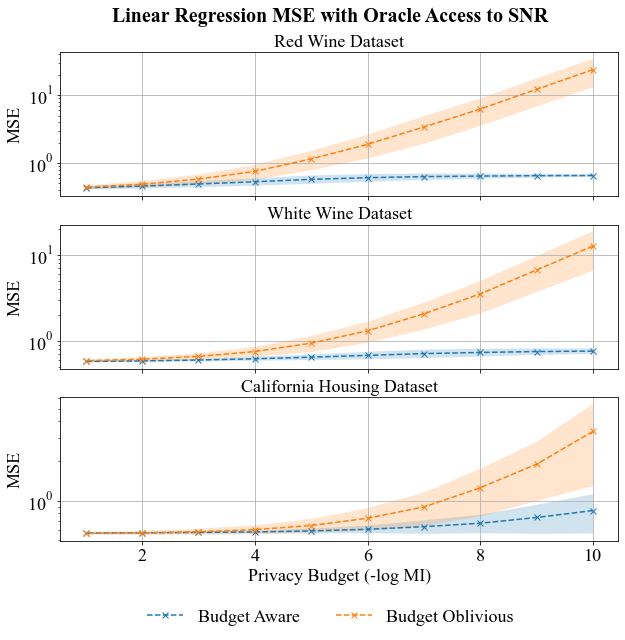

In [101]:
names = ['Red Wine', 'White Wine', 'California Housing']
global_handles, global_labels = [], []
fig, axes = plt.subplots(3, 1, figsize=(10,9), sharex=True)

# dp_lists = {0: ,
#            1: ,
#            2: }
for data_ind, data in enumerate(['wine_red', 'wine_white', 'housing']):

    ax = axes[data_ind]
    mi_range = [2**(x) for x in range(-10, 0)]
    inv_mi_range = [1/mi for mi in mi_range]

    labels = [-np.log2(x) for x in mi_range]
#     labels = inv_mi_range
    print(labels)
    
    
    mses = pickle.load(open(f"results/{data.lower()}_('exact', 0)_opt_mses.pkl", 'rb'))

    xs = []
    priv_aware = []
    priv_obl = []
    priv_aware_bands = []
    priv_obl_bands = []

    for i, inv_mi in enumerate(inv_mi_range):
        xs.append(labels[i])
        
        aware_std = np.std(mses[inv_mi][1], ddof=1)
        aware_mean = np.average(mses[inv_mi][1])
        
        obl_std = np.std(mses[inv_mi][0], ddof=1)
        obl_mean = np.average(mses[inv_mi][0])
        
        priv_aware.append(aware_mean)
        priv_obl.append(obl_mean)
        priv_aware_bands.append((aware_mean-aware_std, aware_mean+aware_std))
        priv_obl_bands.append((obl_mean-obl_std, obl_mean+obl_std))
    print(data)
    print(priv_aware)
    print(priv_obl)
    dp_list = []
    print('---')
    aware_lower = [k[0] for k in priv_aware_bands]
    aware_upper = [k[1] for k in priv_aware_bands]
    obl_lower = [k[0] for k in priv_obl_bands]
    obl_upper = [k[1] for k in priv_obl_bands]
    where_mask = np.ones_like(xs, dtype=bool)

    line1 = ax.plot(xs, priv_aware,  '--x', label='Budget Aware')

    ax.fill_between(xs, aware_lower, aware_upper, where=where_mask, alpha=0.2, linewidth=0)
    
    line2 = ax.plot(xs, priv_obl,  '--x',label='Budget Oblivious')
    ax.fill_between(xs, obl_lower, obl_upper, where=where_mask, alpha=0.2, linewidth=0)

    if data_ind == 0:
        for line in [line1, line2]:
            global_handles.append(line[0])
            global_labels.append(line[0].get_label())
    ax.grid(True)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: f"{val:.1f}"))
    ax.set_yscale('log')  # Set y-axis to logarithmic scale

    ax.tick_params(axis='both', labelsize=18)
    ax.set_title(f"{names[data_ind]} Dataset", fontsize=18, fontweight='normal')
    ax.set_ylabel("MSE", fontsize=18)

ax.set_xlabel("Privacy Budget (-log MI)", fontsize=18)

# fig.subplots_adjust(bottom=0.18)

leg=fig.legend(
    handles=global_handles,
    labels=global_labels,
    ncol = 4,
    bbox_to_anchor=(0.5, -0.03),
    loc='lower center',
    fontsize=18,
    frameon=False
)
title = fig.suptitle("Linear Regression MSE with Oracle Access to SNR", fontsize=20, fontweight="bold", y=0.95)
fig.canvas.draw()
fig.savefig("../figs/regression_exact_lams.pdf", bbox_inches="tight", bbox_extra_artists=(leg, title), pad_inches=0.04)

# fig.tight_layout(rect=[0, 0, 1, 0.96])
# # plt.show()

# plt.savefig('figs/regression_exact_lams.pdf')

In [102]:
dp_results = json.load(open('dp_adassp_results.json'))

In [103]:
dp_results

{'wine_quality_red': {'1.6426117097961406': [0.5950524719168853,
   0.02572051299870462],
  '0.7304317044395013': [0.6324199863534645, 0.02634138189161332],
  '0.3563228120191924': [0.6473330383967234, 0.02726340577647758],
  '0.177101450509287': [0.6568944265988153, 0.028536347019285153],
  '0.08841755656932042': [0.6617653947210531, 0.029238962181311827]},
 'wine_quality_white': {'1.6426117097961406': [0.7589347722894673,
   0.008544414360080509],
  '0.7304317044395013': [0.7679114988961774, 0.009136497930758923],
  '0.3563228120191924': [0.7726624905210454, 0.009436300523406252],
  '0.177101450509287': [0.7744784654824342, 0.009159906566529987],
  '0.08841755656932042': [0.7759307675100128, 0.009277091808657326]},
 'cali_housing': {'1.6426117097961406': [1.262312160086236,
   0.01217591088971955],
  '0.7304317044395013': [1.2884903931093812, 0.009800499827557263],
  '0.3563228120191924': [1.2998084842026765, 0.00782020710853158],
  '0.177101450509287': [1.3055793206036028, 0.0078695

In [104]:
def calc_posterior(mi, prior=0.5, prec = 100000):
    test_vals = [x / prec for x in range(1, prec)]
    max_t = None
    for t in test_vals:
        if t*np.log(t/prior)+(1-t)*np.log((1-t)/(1-prior)) <= mi:
            if  max_t is None or t > max_t:
                max_t = t
    return max_t

def dp_epsilon_to_posterior_success(epsilon):
    return 1 - 1./(1+np.exp(epsilon))

def dp_ps_to_epsilon(ps):
    return np.log(ps / (1-ps))

In [105]:
dp_eps_list = [1.6426117097961406,0.7304317044395013,0.3563228120191924,0.177101450509287,0.08841755656932042]

labels = ['& $\\lambda^{*}_0$ &', '& $\\lambda^{*}_{1/16}$ &', '& $\\lambda^{*}_{1/1024}$ &', '& $\\lambda^{*}_{B}$ &', '& $\\lambda^*_{\\DP}$ &']
for dataset_ind, dataset in enumerate(['wine_red', 'wine_white', 'housing']):
    for key_ind, key in enumerate(["('exact', 0)", "('exact', 16)", "('exact', 1024)", "('exact', 0)", "DP"]):
        mis = [1/4, 1/16, 1/64, 1/256, 1/1024]
        if key_ind <= 3:
            formatted = []
            for mi in mis:
                fname = f'results/{dataset}_{key}_10_mses.pkl'
                if key_ind == 3:
                    data_ind = 1 # aware

                else:
                    data_ind = 0 # oblivious
                mses = pickle.load(open(fname, 'rb'))
                formatted.append(str(round(np.average(mses[1/mi][data_ind]), 2)))
        if key_ind == 4:
            formatted = []
            datasets = ['wine_quality_red', 'wine_quality_white', 'cali_housing']
            for mi_ind in range(len(mis)):
                ps = calc_posterior(mis[mi_ind])
                epsilon = dp_ps_to_epsilon(ps)
                json_epsilon = dp_eps_list[mi_ind]
                assert abs(epsilon - json_epsilon) < 1e-5
                formatted.append(str(round(dp_results[datasets[dataset_ind]][str(json_epsilon)][0], 2)))
        print(f'{labels[key_ind]} ' + ' & '.join(formatted) + '\\\\')
#             print(np.average(mses[c][data_ind]))
    print('\n')

& $\lambda^{*}_0$ & 0.52 & 0.88 & 2.42 & 8.26 & 32.28\\
& $\lambda^{*}_{1/16}$ & 0.52 & 0.58 & 0.84 & 1.95 & 5.87\\
& $\lambda^{*}_{1/1024}$ & 0.65 & 0.65 & 0.65 & 0.65 & 0.65\\
& $\lambda^{*}_{B}$ & 0.49 & 0.58 & 0.64 & 0.65 & 0.66\\
& $\lambda^*_{\DP}$ & 0.6 & 0.63 & 0.65 & 0.66 & 0.66\\


& $\lambda^{*}_0$ & 0.63 & 0.8 & 1.51 & 4.32 & 15.23\\
& $\lambda^{*}_{1/16}$ & 0.61 & 0.69 & 0.98 & 2.2 & 7.06\\
& $\lambda^{*}_{1/1024}$ & 0.76 & 0.76 & 0.76 & 0.77 & 0.78\\
& $\lambda^{*}_{B}$ & 0.62 & 0.69 & 0.76 & 0.78 & 0.78\\
& $\lambda^*_{\DP}$ & 0.76 & 0.77 & 0.77 & 0.77 & 0.78\\


& $\lambda^{*}_0$ & 0.62 & 0.83 & 1.58 & 4.84 & 16.36\\
& $\lambda^{*}_{1/16}$ & 0.57 & 0.61 & 0.77 & 1.47 & 4.15\\
& $\lambda^{*}_{1/1024}$ & 1.07 & 1.07 & 1.07 & 1.1 & 1.18\\
& $\lambda^{*}_{B}$ & 0.57 & 0.61 & 0.72 & 0.94 & 1.17\\
& $\lambda^*_{\DP}$ & 1.26 & 1.29 & 1.3 & 1.31 & 1.31\\




In [107]:
for dataset_ind, dataset in enumerate(['wine_red', 'wine_white', 'housing']):
    for snr in ['opt', 0.1, 1, 10]:
        mis = [1/4, 1/16, 1/64, 1/256, 1/1024]
        row_res = []
        if snr != 'opt':
            row_res.append(f'& {1./snr}')
        else:
            row_res.append(f'& Oracle')
        for mi in mis:
            fname = f"results/{dataset}_('exact', 0)_{snr}_mses.pkl"
            mses = pickle.load(open(fname, 'rb'))
            obl_mses = mses[1/mi][0]
            obl_mean = np.average(obl_mses)
            aware_mses = mses[1/mi][1]
            aware_mean = np.average(aware_mses)
            fin = '\\tup' + "{" + f'{round(obl_mean, 2)}' + "}" + "{" + f'{round(aware_mean, 2)}' + "}"
            row_res.append(fin)
        print(' & '.join(row_res) + "\\\\ ")
        print('\cline{2-7}')

    print('\n')

& Oracle & \tup{0.49}{0.46} & \tup{0.75}{0.53} & \tup{1.88}{0.61} & \tup{6.23}{0.64} & \tup{23.71}{0.65}\\ 
\cline{2-7}
& 10.0 & \tup{0.52}{0.52} & \tup{0.9}{0.88} & \tup{2.46}{2.18} & \tup{8.53}{5.84} & \tup{31.85}{9.53}\\ 
\cline{2-7}
& 1.0 & \tup{0.52}{0.51} & \tup{0.9}{0.8} & \tup{2.33}{1.28} & \tup{8.48}{1.32} & \tup{32.3}{0.96}\\ 
\cline{2-7}
& 0.1 & \tup{0.52}{0.49} & \tup{0.88}{0.58} & \tup{2.42}{0.64} & \tup{8.26}{0.65} & \tup{32.28}{0.66}\\ 
\cline{2-7}


& Oracle & \tup{0.61}{0.59} & \tup{0.75}{0.62} & \tup{1.31}{0.68} & \tup{3.51}{0.73} & \tup{12.54}{0.76}\\ 
\cline{2-7}
& 10.0 & \tup{0.63}{0.63} & \tup{0.8}{0.81} & \tup{1.52}{1.5} & \tup{4.34}{3.81} & \tup{15.78}{9.14}\\ 
\cline{2-7}
& 1.0 & \tup{0.63}{0.63} & \tup{0.81}{0.78} & \tup{1.52}{1.21} & \tup{4.32}{1.74} & \tup{15.4}{1.58}\\ 
\cline{2-7}
& 0.1 & \tup{0.63}{0.62} & \tup{0.8}{0.69} & \tup{1.51}{0.76} & \tup{4.32}{0.78} & \tup{15.23}{0.78}\\ 
\cline{2-7}


& Oracle & \tup{0.57}{0.57} & \tup{0.6}{0.58} & \tup{0.73}{0